# Week 11: ML Review

### Setup

Run the following 2 cells to import all necessary libraries and helpers for this homework

In [2]:
!wget -q https://github.com/PSAM-5020-2026S-A/5020-utils/raw/main/src/data_utils.py
!wget -q https://github.com/PSAM-5020-2026S-A/5020-utils/raw/main/src/image_utils.py
!wget -qO- https://github.com/PSAM-5020-2026S-A/5020-utils/releases/latest/download/lfw.tar.gz | tar xz

In [3]:
from random import randrange
import pandas as pd

from sklearn.metrics import classification_report, confusion_matrix

from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from data_utils import LFWUtils
from data_utils import classification_error, display_confusion_matrix
from image_utils import make_image

## Face Unlock

Let's train a model to detect our face. We can think of this as a simpler version of one of the components inside something like the face ID software on our phones.

We'll skip the face detection part, which is when we find faces in an image, and assume we can get cropped and aligned faces out of images or video streams. We'll look at face detection later in the semester.

This is a slightly different kind of problem from the classification exercise we did in class, but the process is mostly the same.

We will use a dataset with other people's faces, but in the end we are only interested on how well our model detects our face.

### We Always Start with the Data

The dataset we're using is inside `./data/images/lfw/cropped`. It's a subset of the [Labeled Faces in the Wild](https://vis-www.cs.umass.edu/lfw/) dataset.

Take a look at the directory.

What's there?

How's the data organized and labeled?

### Loading the Data

Since we're not interested in generic classification, and measuring how we do on unlabeled data, this whole dataset is labeled, and we can read it into `train` and `test` subsets by calling the `train_test_split()` function of the `LFWUtils` class.

This function takes an optional parameter that specifies what portion of the data should be used for the `test` dataset. We can start with the default value of $0.5$.

In [4]:
train, test = LFWUtils.train_test_split(dir="./data/image/lfw/cropped", test_pct=0.5)

### Looking at the Data

Ok. Data is loaded.

What's in the data? How is it actually organized?

Take a look at the objects that were returned in each of the $2$ variables.

How big are our datasets?

Take a look at the `LABELS` and `L2I` members of the `LFWUtils` class (`LFWUtils.LABELS` and `LFWUtils.L2I`).

In [5]:
# TODO: look at dataset objects (train and test variables). What's in them?
print(train.keys())
print(test.keys())
# TODO: how big are them? (how many records?)
print("train size:", len(train["files"]))
print("test size:", len(test["files"]))
# TODO: how many labels do they have?
print("train labels:", len(set(train["labels"])))
print("test labels:", len(set(test["labels"])))
# TODO: what are the labels
print(LFWUtils.LABELS)
print(LFWUtils.L2I)

dict_keys(['pixels', 'labels', 'files'])
dict_keys(['pixels', 'labels', 'files'])
train size: 445
test size: 438
train labels: 25
test labels: 25
['annan', 'arroyo', 'berlusconi', 'blair', 'bushgw', 'bushl', 'chavez', 'clintonb', 'erdogan', 'fox', 'giuliani', 'jolie', 'koizumi', 'lopez', 'lula', 'mauresmo', 'moohyun', 'powell', 'putin', 'ryder', 'schwarzenegger', 'sukarnoputri', 'watts', 'williams', 'woods']
{'annan': 0, 'arroyo': 1, 'berlusconi': 2, 'blair': 3, 'bushgw': 4, 'bushl': 5, 'chavez': 6, 'clintonb': 7, 'erdogan': 8, 'fox': 9, 'giuliani': 10, 'jolie': 11, 'koizumi': 12, 'lopez': 13, 'lula': 14, 'mauresmo': 15, 'moohyun': 16, 'powell': 17, 'putin': 18, 'ryder': 19, 'schwarzenegger': 20, 'sukarnoputri': 21, 'watts': 22, 'williams': 23, 'woods': 24}


### Visualizing the Data

We can open some random images to make sure the content of our datasets make sense.

Our `LFWUtils` class has some member variables that hold the image dimensions (`LFWUtils.IMAGE_SIZE`, `LFWUtils.IMAGE_WIDTH`, `LFWUtils.IMAGE_HEIGHT`)

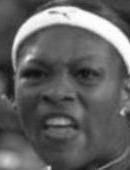

id: 23 
label: williams 
from: williams-041.jpg


In [6]:
train_size = len(train["labels"])
ridx = randrange(0, train_size)

label_id = train["labels"][ridx]

display(make_image(train["pixels"][ridx], width=LFWUtils.IMAGE_SIZE[0]))

print("id:", label_id,
      "\nlabel:", LFWUtils.LABELS[label_id],
      "\nfrom:", train["files"][ridx])

### Adding your images

Create a directory in the `dataset` directory for your images. Give it a one-word name, like your last name, your New School id or your initials. For example, mine is called `tgh` and is located at: `./data/images/lfw/cropped/tgh`.

Now, add between $20$ and $30$ images of your face to your directory. 

The images should be just like the ones that are already there for the other people:
- $130$ pixels wide
- $170$ pixels tall
- single-channel grayscale
- jpeg format
- named `label-number.jpg` (for example: `tgh-000.jpg`)

Feel free to do this manually using Photoshop or any other image editing software, but the easiest way is to use this interface that automatically crops faces out of pictures and creates images in the correct format:

### [Face Align](https://huggingface.co/spaces/visualizedata/PSAM5020-FaceAlign-Gradio)

It will also align the faces and put the eyes in a consistent location. There's even an option to capture pictures from a live camera stream.

### Reload Dataset

Just run the `train_test_split()` again.

### PCA, Classification, etc etc etc

Now that we have added our images to the dataset, let's train a classifier and see how well it performs on not just classification, but on recognizing our face.

The images are $130$ x $170$ ($22\text{,}100$ pixels), so let's do `PCA`. We can aim for an explained variance value of about $80\%$, and adjust that later if we find necessary.

Once we have the PCs for our training dataset in a `DataFrame` we can add a `label` column to it with the correct labels we have in `train["labels"]`.

We can also create a `DataFrame` for testing now by using the same `PCA` object to `transform()` the `test["pixels"]` data.

Since we won't train anything with the test dataset, it's ok to just keep the labels in `test["labels"]` as they are.

In [7]:
# TODO: create PCA, fit and transform train data
face_pca = PCA(n_components=0.9).set_output(transform="pandas")
train_df = face_pca.fit_transform(train["pixels"])
# TODO: check PCA captured variance
print("captured variance:", sum(face_pca.explained_variance_ratio_))
# TODO: prepare DataFrame for training (add label column)
train_df["label"] = train["labels"]
# TODO: create the test DataFrame by running PCA on the test data
test_df = face_pca.transform(test["pixels"])

captured variance: 0.9010261593416843


We can use the following cell to take a look at our images and their reconstructions.

This assumes the `DataFrame` is called `train_df` and the `PCA` object is called `face_pca`. Adjust these if necessary.

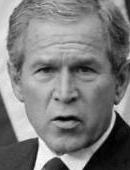

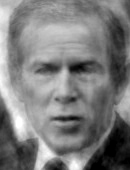

In [8]:
train_size = len(train["labels"])
ridx = randrange(0, train_size)

pca_pixels = face_pca.inverse_transform(
    train_df.iloc[[ridx]].drop(columns=["label"])
)
display(make_image(train["pixels"][ridx], width=LFWUtils.IMAGE_SIZE[0]))
display(make_image(pca_pixels, width=LFWUtils.IMAGE_SIZE[0]))

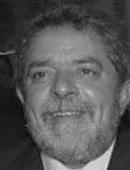

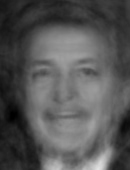

In [10]:

# filter the DataFrame by our label
awesome_df = train_df[train_df["label"] == LFWUtils.L2I["lula"]]

# index of image with our label
img_idx = 0
awesome_idx = awesome_df.index[img_idx]

# reconstruct image
pca_pixels = face_pca.inverse_transform(awesome_df.iloc[[img_idx]].drop(columns=["label"]))

display(make_image(train["pixels"][awesome_idx], width=LFWUtils.IMAGE_WIDTH))
display(make_image(pca_pixels, width=LFWUtils.IMAGE_WIDTH))

### Interpretation

<span style="color:hotpink;">
Do these make sense ? Do they look "recognizable" ? How do they change as a function of `PCA` <code>n_components</code> ?
</span>

<span style="color:white;"> Yes the images are still recognizable but a bit blurry. More PCA components make them clearer, fewer make them more blurry.</span>

Now, back to classifying...

Maybe start with `RandomForestClassifier()` or `SVC()`...

In [11]:
# TODO: create a classifier
rfc = RandomForestClassifier()
# TODO: separate input and output columns from the train DataFrame
train_nolabel_df = train_df.drop(columns=["label"])

# TODO: train model using train data and labels
rfc.fit(train_nolabel_df, train_df["label"])

# TODO: run prediction on train data
train_predictions = rfc.predict(train_nolabel_df)

### Validate model with training data

error: 0.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        16
           1       1.00      1.00      1.00        22
           2       1.00      1.00      1.00        17
           3       1.00      1.00      1.00        24
           4       1.00      1.00      1.00        24
           5       1.00      1.00      1.00        19
           6       1.00      1.00      1.00        24
           7       1.00      1.00      1.00        14
           8       1.00      1.00      1.00        15
           9       1.00      1.00      1.00        16
          10       1.00      1.00      1.00        13
          11       1.00      1.00      1.00        10
          12       1.00      1.00      1.00        24
          13       1.00      1.00      1.00        11
          14       1.00      1.00      1.00        24
          15       1.00      1.00      1.00        11
          16       1.00      1.00      1.00        16
          17    

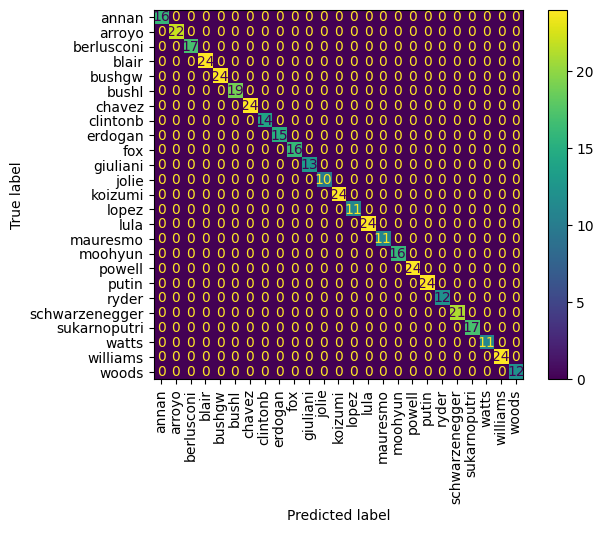

In [12]:
# measure classification error
print("error:", classification_error(train["labels"], train_predictions))

# look at precision/recall from classification_report
print(classification_report(train["labels"], train_predictions))

# look at confusion matrix
display_confusion_matrix(train["labels"], train_predictions, LFWUtils.LABELS)

### Interpretation

<span style="color:hotpink;">
How does the confusion matrix look ? What does it mean ?
</span>

<span style="color:white;">Most values are on the diagonal so the model is predicting correctly most of the time, there are almost no off diagonal values  meaning very few mistakes between different people.</span>

### Validate model with testing data

error: 0.6187214611872146
              precision    recall  f1-score   support

           0       0.11      0.07      0.08        15
           1       0.52      0.50      0.51        22
           2       0.00      0.00      0.00        16
           3       0.14      0.21      0.17        24
           4       0.29      0.58      0.38        24
           5       0.62      0.79      0.70        19
           6       0.29      0.33      0.31        24
           7       0.50      0.21      0.30        14
           8       1.00      0.14      0.25        14
           9       0.60      0.19      0.29        16
          10       0.00      0.00      0.00        13
          11       0.50      0.20      0.29        10
          12       0.49      0.79      0.60        24
          13       0.33      0.20      0.25        10
          14       0.36      0.58      0.44        24
          15       0.00      0.00      0.00        10
          16       0.53      0.50      0.52        16
 

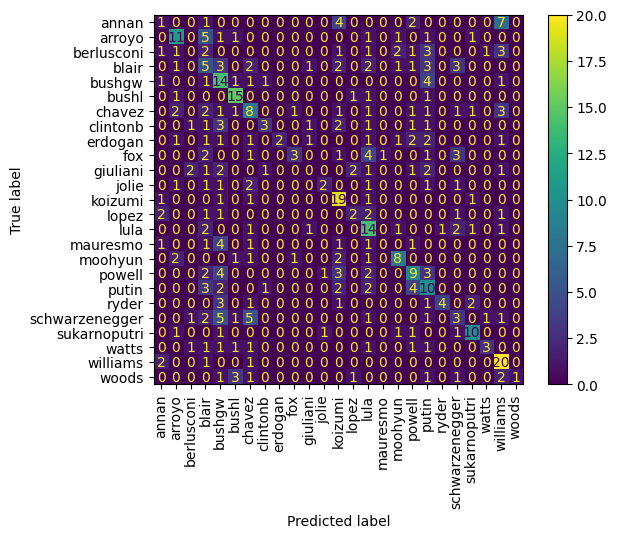

In [13]:
# TODO: run prediction on test data
test_predictions = rfc.predict(test_df)

# TODO: measure classification error
print("error:", classification_error(test["labels"], test_predictions))

# TODO: look at precision/recall from classification_report
print(classification_report(test["labels"], test_predictions))

# TODO: look at confusion matrix
display_confusion_matrix(test["labels"], test_predictions, LFWUtils.LABELS)

### Different Classifiers

Try changing the classifier type above, or some of its parameters, to see if the overall accuracy can be improved.

Some things to try:
- `SVC(kernel="linear")`: this changes the type of curve the model tries to use to separate our classes. The more complex default type (`rbf`) might be over-fitting the data. We can experiment with `linear` or `poly` curves.
- `LogisticRegression()`: the classification that fits statistical modeling functions (bell curves) to our data.


### Hyper-parameter Optimization

Each model type has a handful of parameters that can be adjusted and optimized.

For example, we could add "regularization" to a `LogisticRegression` classifier with `C=0.1`.

Regularization is a process that makes training harder by setting more restrictions on the kind of answers it can give.

This can be restrictions like:
- keep all calculated parameters close to $0$
- minimize the number of non-zero parameters used
- keep all parameters positive

The result is slightly worse performance on the training dataset, but hopefully better generalization of the model and better performance on the test dataset.

error: 0.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        16
           1       1.00      1.00      1.00        22
           2       1.00      1.00      1.00        17
           3       1.00      1.00      1.00        24
           4       1.00      1.00      1.00        24
           5       1.00      1.00      1.00        19
           6       1.00      1.00      1.00        24
           7       1.00      1.00      1.00        14
           8       1.00      1.00      1.00        15
           9       1.00      1.00      1.00        16
          10       1.00      1.00      1.00        13
          11       1.00      1.00      1.00        10
          12       1.00      1.00      1.00        24
          13       1.00      1.00      1.00        11
          14       1.00      1.00      1.00        24
          15       1.00      1.00      1.00        11
          16       1.00      1.00      1.00        16
          17    

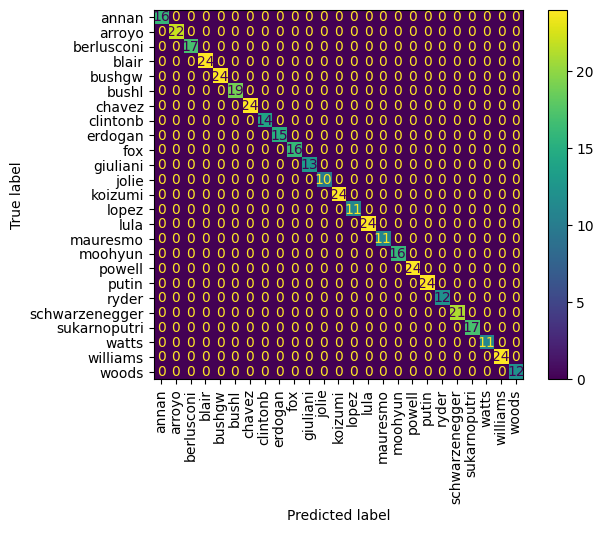

In [14]:
# TODO: try LogisticRegression() and/or SVC(kernel="linear")
svc = SVC(kernel="linear")
# preparing the data
train_nolabel_df = train_df.drop(columns=["label"])
# model
svc.fit(train_nolabel_df, train_df["label"])
# predictions
train_predictions = svc.predict(train_nolabel_df)

# TODO: does adding features (increasing PCA components) help ?
print("error:", classification_error(train["labels"], train_predictions))
print(classification_report(train["labels"], train_predictions))
display_confusion_matrix(train["labels"], train_predictions, LFWUtils.LABELS)

### Interpretation

<span style="color:hotpink;">
How does THIS confusion matrix look ? What does it mean ? How does it perform for your pictures ?
</span>

<span style="color:white;">The confusion matrix is almost entirely diagonal which shows the model is classifying most samples correctly with very few mistakes. This means the model has learned the training data well and is identifying the target class accurately with high precision and recall.</span>

### Precision and Recall

Accuracy, which is the complement of our `classification_error` value, is the measurement that is optimized during the `RandomForestClassifier` training process.

If we were training a regular classifier, we would look at `accuracy` (or `classification_error`) to determine if our model's performance is acceptable.

Since we're working on a personal face recognition model, we don't really care about overall accuracy, but instead are more interested in the `precision` and `recall` values for the classification of our particular images.

We don't want overall accuracy to be horrible, but we can be more specific in this case and be happy if the correct portion of our confusion matrix looks good.

Calculate the `precision` and `recall` values for the classification of your images.

In [15]:
from sklearn.metrics import precision_score, recall_score

my_label = 23

# TODO: calculate precision
precision = precision_score(
    test["labels"],
    test_predictions,
    labels=[my_label],
    average="macro"
)

# TODO: calculate recall
recall = recall_score(
    test["labels"],
    test_predictions,
    labels=[my_label],
    average="macro"
)

print("precision:", precision)
print("recall:", recall)


precision: 0.4878048780487805
recall: 0.8333333333333334


### Interpretation

<span style="color:hotpink;">
How is it performing for your images ? Which value, precision or recall, is higher ? What does that mean ?
</span>

<span style="color:white;">The model is performing well for my images, the recall is higher than precision which means the model is able to find most of my images correctly but it sometimes predicts my face for images that are actually other people.</span>

We can run the following cell to see which classes have the highest `precision` and `recall` scores:

In [16]:
print("top precision:", LFWUtils.top_precision(test["labels"], test_predictions, top=5))
print("top recall:", LFWUtils.top_recall(test["labels"], test_predictions, top=5))

top precision: ['woods', 'erdogan', 'ryder', 'bushl', 'sukarnoputri']
top recall: ['williams', 'koizumi', 'bushl', 'sukarnoputri', 'bushgw']
